In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
import warnings

# Suppress all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df=pd.read_csv(r'C:\Users\matti\OneDrive\Desktop\MASTER\Module 3\Unit 5\Seminar Activity\ebola_2014_2016_clean.csv')

# Visualize the Data Set structure

In [4]:
df.shape

(2485, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 4 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Country                                                     2485 non-null   object 
 1   Date                                                        2485 non-null   object 
 2   Cumulative no. of confirmed, probable and suspected cases   2477 non-null   float64
 3   Cumulative no. of confirmed, probable and suspected deaths  2485 non-null   float64
dtypes: float64(2), object(2)
memory usage: 77.8+ KB


In [3]:
df.head()

,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
0,Guinea,2014-08-29,648.0,430.0
1,Nigeria,2014-08-29,19.0,7.0
2,Sierra Leone,2014-08-29,1026.0,422.0
3,Liberia,2014-08-29,1378.0,694.0
4,Sierra Leone,2014-09-05,1261.0,491.0


# We can see we have some null values

In [8]:
df[df.isna().any(axis=1)]

,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths"
301,United Kingdom,2015-01-08,NaN,0.0
302,Mali,2015-01-08,NaN,6.0
306,Mali,2015-01-09,NaN,6.0
308,United Kingdom,2015-01-09,NaN,0.0
312,United Kingdom,2015-01-12,NaN,0.0
314,Mali,2015-01-12,NaN,6.0
316,United Kingdom,2015-01-13,NaN,0.0
317,Mali,2015-01-13,NaN,6.0


# We are going to remove the Nan Value

In [13]:
df1=df[~(df.isna().any(axis=1))]

# Mining the datetimes 

In [14]:
import datetime as dt

In [63]:
df1['Date']=pd.to_datetime(df1['Date'],format='%Y-%m-%d')

C:\Users\matti\AppData\Local\Temp\ipykernel_18828\3353261762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Date']=pd.to_datetime(df1['Date'],format='%Y-%m-%d')


In [62]:
df1['year'] = df1['Date'].dt.year
df1['month']=df1['Date'].dt.month

C:\Users\matti\AppData\Local\Temp\ipykernel_18828\2637279800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['year'] = df1['Date'].dt.year
C:\Users\matti\AppData\Local\Temp\ipykernel_18828\2637279800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['month']=df1['Date'].dt.month


In [21]:
df1

,Country,Date,"Cumulative no. of confirmed, probable and suspected cases","Cumulative no. of confirmed, probable and suspected deaths",year,month
0,Guinea,2014-08-29,648.0,430.0,2014,8
1,Nigeria,2014-08-29,19.0,7.0,2014,8
2,Sierra Leone,2014-08-29,1026.0,422.0,2014,8
3,Liberia,2014-08-29,1378.0,694.0,2014,8
4,Sierra Leone,2014-09-05,1261.0,491.0,2014,9
...,...,...,...,...,...,...
2480,Liberia,2016-03-23,10666.0,4806.0,2016,3
2481,Italy,2016-03-23,1.0,0.0,2016,3
2482,Liberia,2016-03-23,5.0,4.0,2016,3
2483,Nigeria,2016-03-23,20.0,8.0,2016,3


# Cases and Death over the time

In [49]:
cases=df1.groupby('year')['Cumulative no. of confirmed, probable and suspected cases'].sum().reset_index()
deaths=df1.groupby('year')['Cumulative no. of confirmed, probable and suspected deaths'].sum().reset_index()

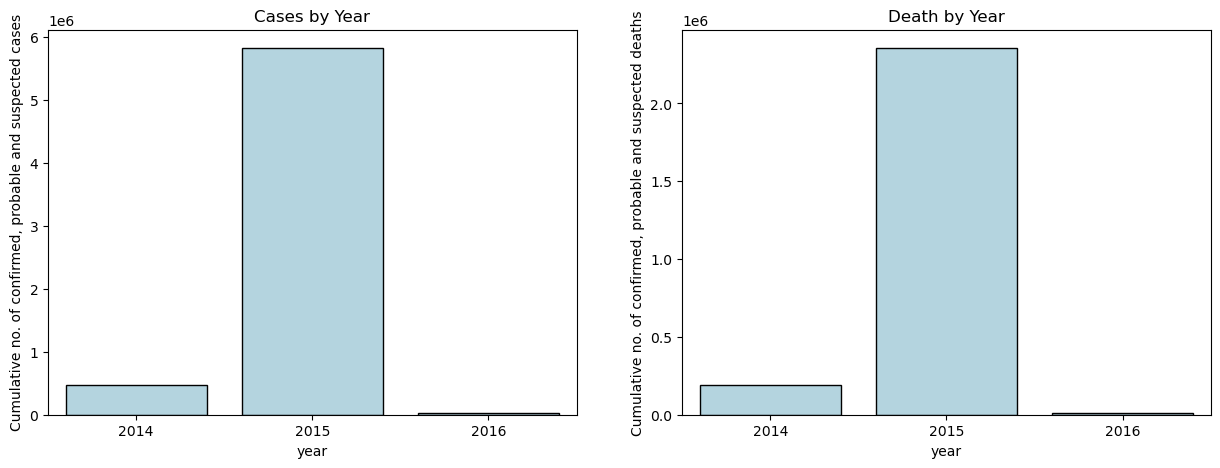

In [51]:
fig,axis=plt.subplots(1,2,figsize=(15,5))
sns.barplot(x=cases['year'],y=cases['Cumulative no. of confirmed, probable and suspected cases'],color='lightblue',edgecolor='black',ax=axis[0])
axis[0].set_title('Cases by Year');
sns.barplot(x=deaths['year'],y=deaths['Cumulative no. of confirmed, probable and suspected deaths'],color='lightblue',edgecolor='black',ax=axis[1])
axis[1].set_title('Death by Year');

In [75]:
pd.crosstab(index=df1['year'],columns=df1['Country'],values=df1['Cumulative no. of confirmed, probable and suspected deaths'],aggfunc='sum')

Country,Guinea,Italy,Liberia,Mali,Nigeria,Senegal,Sierra Leone,Spain,United Kingdom,United States of America
year,,,,,,,,,,
2014,40462.0,NaN,95625.0,101.0,303.0,0.0,51945.0,0.0,NaN,25.0
2015,520071.0,0.0,999395.0,1296.0,1728.0,0.0,832934.0,0.0,0.0,216.0
2016,2536.0,0.0,4813.0,6.0,8.0,0.0,3955.0,0.0,0.0,1.0


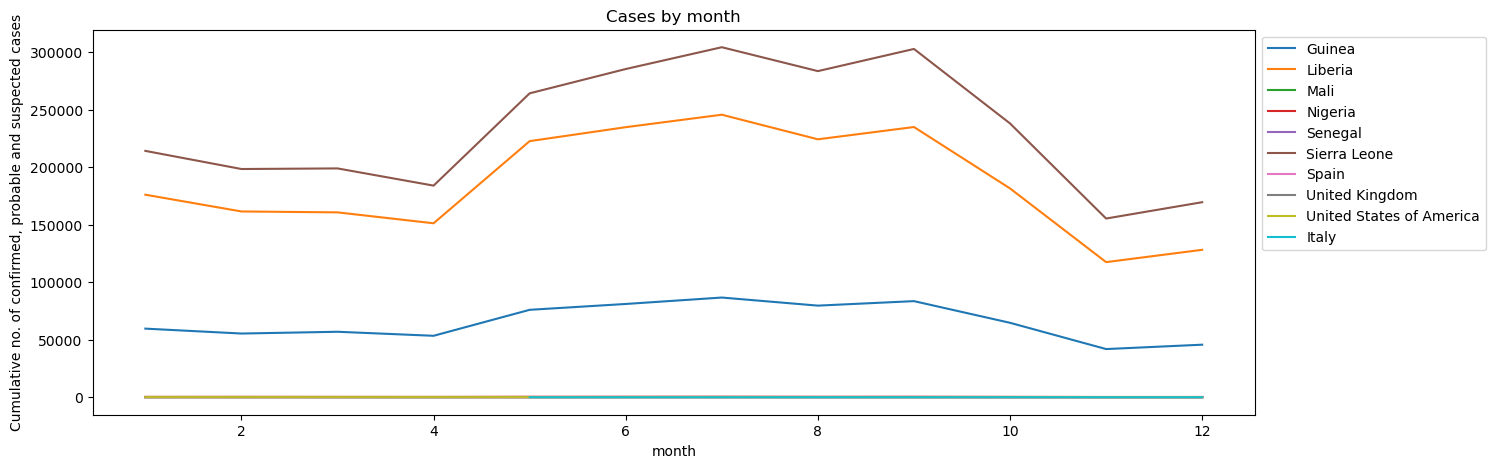

In [71]:
df_2025=df1[df1['year']==2015].groupby(['month','Country'])['Cumulative no. of confirmed, probable and suspected cases'].sum().reset_index()

plt.figure(figsize=(15,5))
sns.lineplot(x=df_2025['month'],y=df_2025['Cumulative no. of confirmed, probable and suspected cases'],hue=df_2025['Country'])
plt.legend(bbox_to_anchor = (1,1))
plt.title('Cases by month');

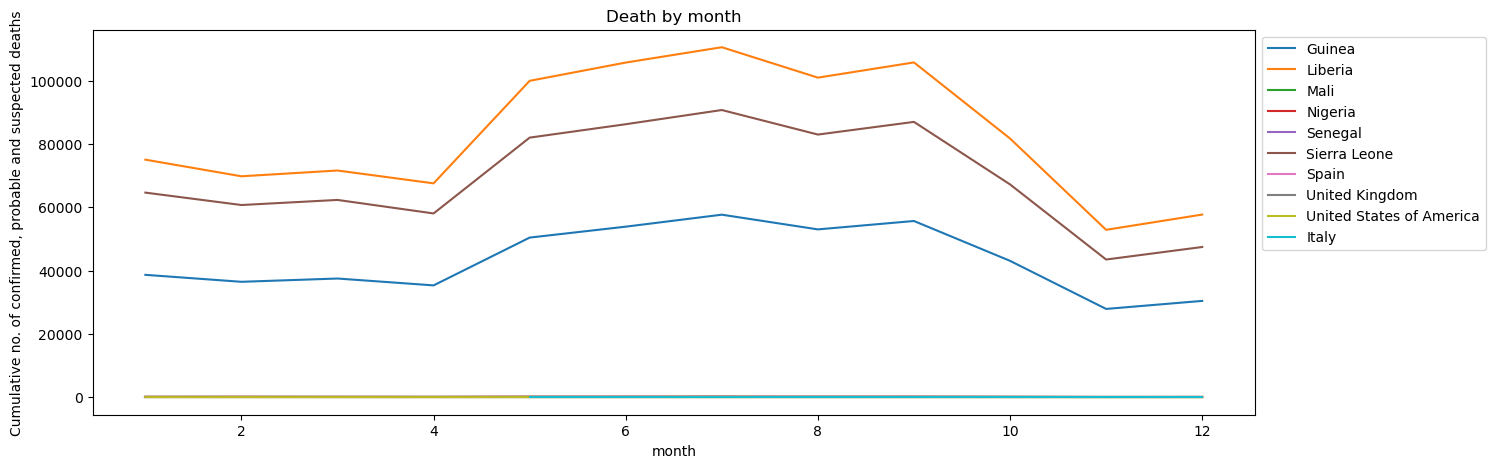

In [70]:
d_2025=df1[df1['year']==2015].groupby(['month','Country'])['Cumulative no. of confirmed, probable and suspected deaths'].sum().reset_index()

plt.figure(figsize=(15,5))
sns.lineplot(x=d_2025['month'],y=d_2025['Cumulative no. of confirmed, probable and suspected deaths'],hue=d_2025['Country'])
plt.legend(bbox_to_anchor = (1,1))
plt.title('Death by month');

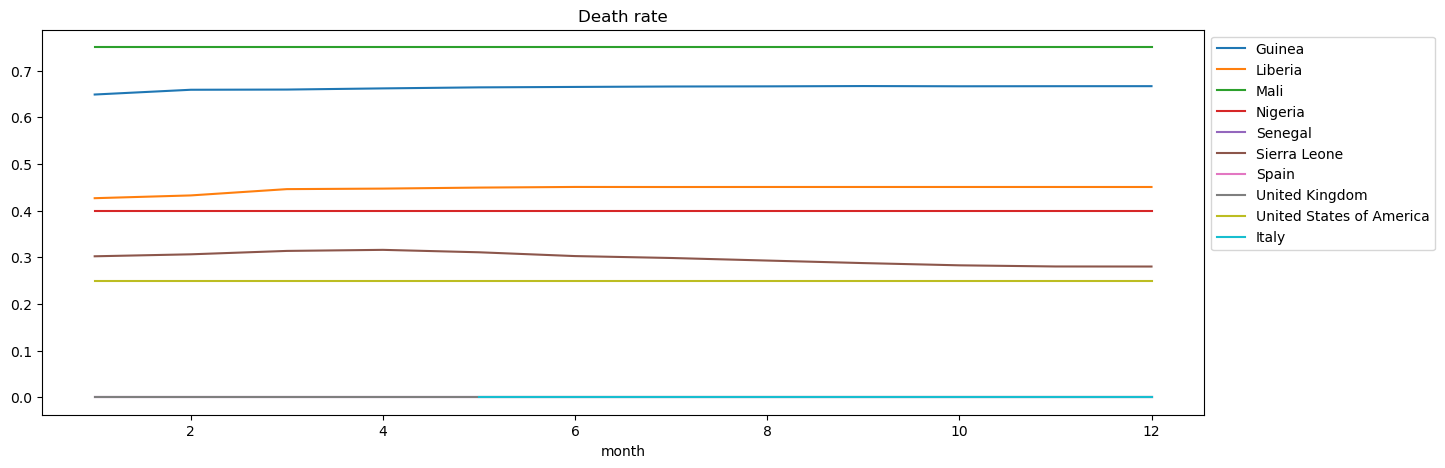

In [69]:
d_2025=df1[df1['year']==2015].groupby(['month','Country'])[['Cumulative no. of confirmed, probable and suspected cases','Cumulative no. of confirmed, probable and suspected deaths']].sum().reset_index()

plt.figure(figsize=(15,5))
sns.lineplot(x=d_2025['month'],y=d_2025['Cumulative no. of confirmed, probable and suspected deaths']/d_2025['Cumulative no. of confirmed, probable and suspected cases'],hue=d_2025['Country'])
plt.legend(bbox_to_anchor = (1,1))
plt.title('Death rate');

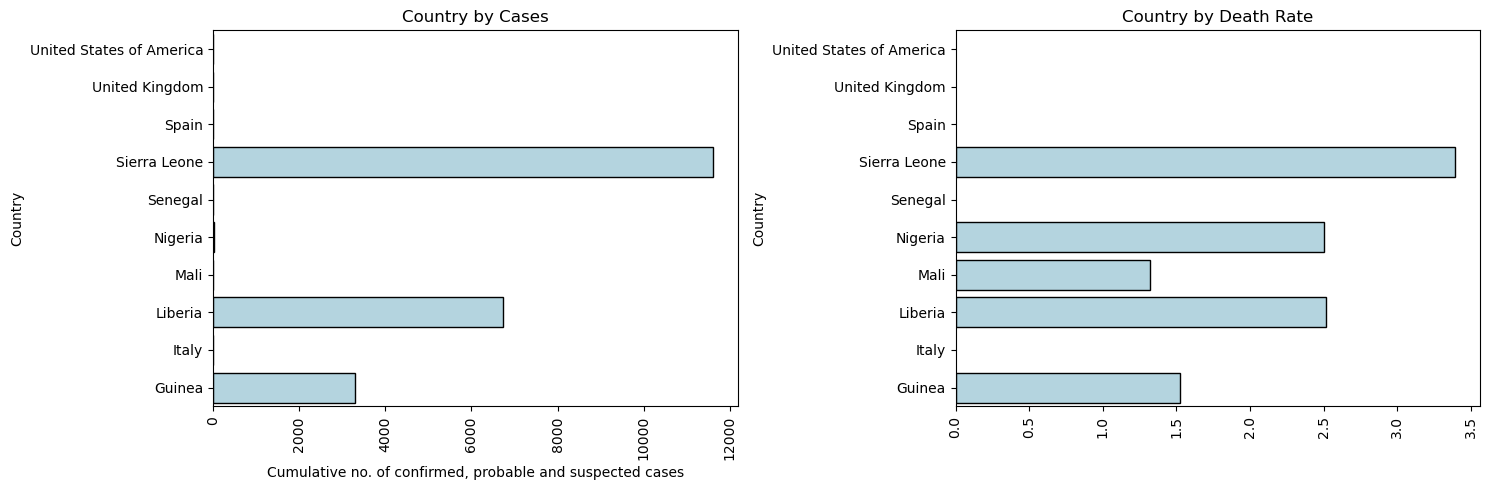

In [39]:
fig,axis=plt.subplots(1,2,figsize=(15,5),dpi=100)

sns.barplot(x=df1['Cumulative no. of confirmed, probable and suspected cases'],y=df1['Country'].sort_values(ascending=False),color='lightblue',edgecolor='black',errorbar=None,ax=axis[0])
axis[0].tick_params(axis='x', rotation=90)
axis[0].set_title('Country by Cases');

sns.barplot(x=df1['Cumulative no. of confirmed, probable and suspected cases']/df1['Cumulative no. of confirmed, probable and suspected deaths'],y=df1['Country'].sort_values(ascending=False),color='lightblue',edgecolor='black',errorbar=None,ax=axis[1])
axis[1].tick_params(axis='x', rotation=90)
axis[1].set_title('Country by Death Rate');

plt.tight_layout()